## NDVI Smoothing

Processing: Yanamarey Impacted...


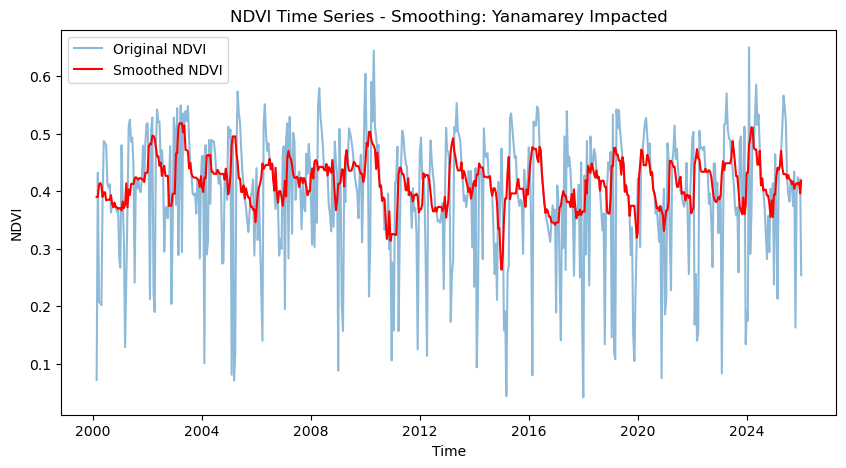

Successfully saved smoothed data to: /Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanImpNSmooth.csv

Processing: Yanamarey Non-Impacted...


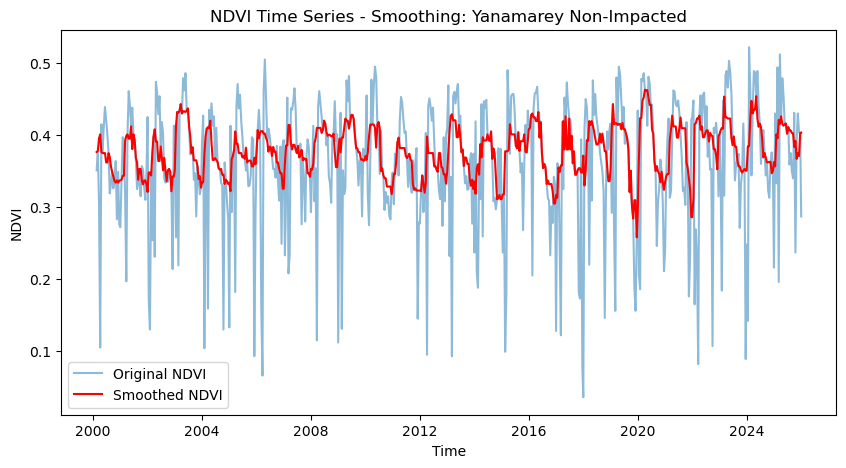

Successfully saved smoothed data to: /Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanNonNSmooth.csv

Processing: Ritacuba Blanco Impacted...


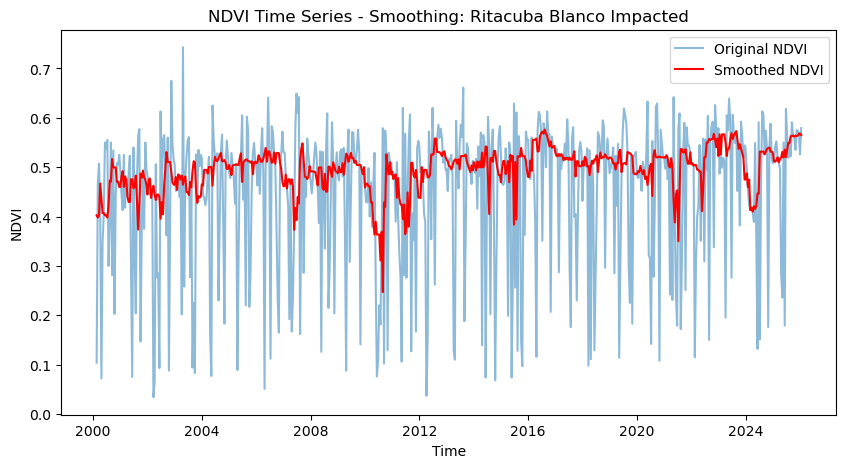

Successfully saved smoothed data to: /Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBImpNSmooth.csv

Processing: Ritacuba Blanco Non-Impacted...


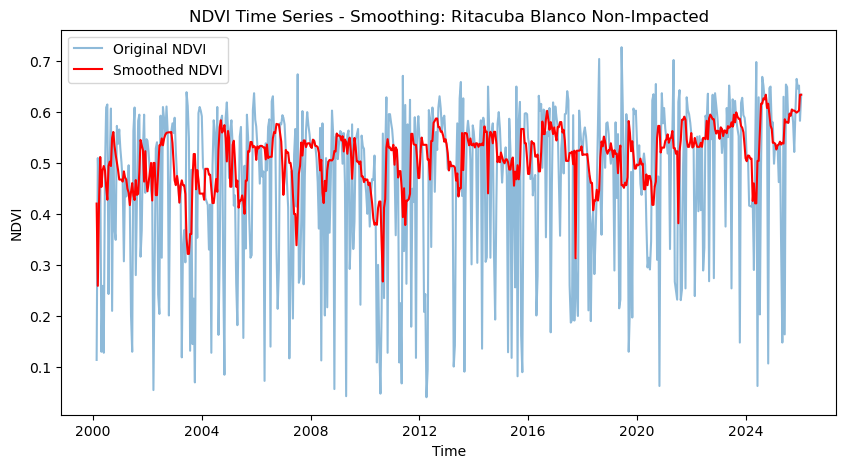

Successfully saved smoothed data to: /Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBNonNSmooth.csv

All files processed successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Update this path to the location of the GlacierProject folder on your computer
BASE_DIR = '/path/to/GlacierProject' 

# ==========================================
# 1. DEFINE BATCH PROCESSING DICTIONARY
# ==========================================
# This pairs every input file with its corresponding output file and a title for the plot
files_to_process = [
    {
        "name": "Yanamarey Impacted",
        "input": os.path.join(BASE_DIR, 'RawData', 'NDVI', 'Y_ImpNDVI_Raw.csv'),
        "output": os.path.join(BASE_DIR, 'Intermediate', 'NDVI', 'YanImpNSmooth.csv')
    },
    {
        "name": "Yanamarey Non-Impacted",
        "input": os.path.join(BASE_DIR, 'RawData', 'NDVI', 'Y_NonNDVI_Raw.csv'),
        "output": os.path.join(BASE_DIR, 'Intermediate', 'NDVI', 'YanNonNSmooth.csv')
    },
    {
        "name": "Ritacuba Blanco Impacted",
        "input": os.path.join(BASE_DIR, 'RawData', 'NDVI', 'RB_IMP_NDVI_FEB.csv'),
        "output": os.path.join(BASE_DIR, 'Intermediate', 'NDVI', 'RBImpNSmooth.csv')
    },
    {
        "name": "Ritacuba Blanco Non-Impacted",
        "input": os.path.join(BASE_DIR, 'RawData', 'NDVI', 'RB_NON_NDVI_FEB.csv'),
        "output": os.path.join(BASE_DIR, 'Intermediate', 'NDVI', 'RBNonNSmooth.csv')
    }
]

# ==========================================
# 2. SMOOTHING FUNCTION
# ==========================================
def iammf_smoothing(df, n=2, max_window=30):                                     
    df = df.sort_values(by='time').reset_index(drop=True)
    df['NDVI_smoothed'] = df['NDVI'].copy()

    for i in range(len(df)):
        window_size = 6  # Start with a 3-day window and increase from there                           
        valid_values = []

        while window_size <= max_window:
            left_window = df.iloc[max(0, i - window_size):i]['NDVI'].dropna().tolist()
            right_window = df.iloc[i+1:min(len(df), i + window_size + 1)]['NDVI'].dropna().tolist()

            if len(left_window) + len(right_window) >= n:
                valid_values = left_window + right_window
                median = np.median(valid_values)
                mad = np.median(np.abs(valid_values - median))

                if len(valid_values) >= n + 1:
                    prev_median = df.loc[i, 'NDVI_smoothed']
                    if abs(median - prev_median) < 0.5 * mad:                    
                        break  # Converged

                df.at[i, 'NDVI_smoothed'] = median

            window_size += 1  # Expand window

    return df

# ==========================================
# 3. LOOP THROUGH FILES AND PROCESS
# ==========================================
for file_data in files_to_process:
    print(f"Processing: {file_data['name']}...")
    
    # Load
    df = pd.read_csv(file_data['input'])
    
    # Smooth
    df_smoothed = iammf_smoothing(df)
    
    # Plot
    df_smoothed['time'] = pd.to_datetime(df_smoothed['time'])
    plt.figure(figsize=(10, 5))
    plt.plot(df_smoothed['time'], df_smoothed['NDVI'], label='Original NDVI', alpha=0.5)
    plt.plot(df_smoothed['time'], df_smoothed['NDVI_smoothed'], label='Smoothed NDVI', color='red')
    plt.xlabel('Time')
    plt.ylabel('NDVI')
    plt.legend()
    plt.title(f'NDVI Time Series - Smoothing: {file_data["name"]}')
    plt.show()
    
    # Export
    df_smoothed.to_csv(file_data['output'], index=False)
    print(f"Successfully saved smoothed data to: {file_data['output']}\n")

print("All files processed successfully!")

## Correlation

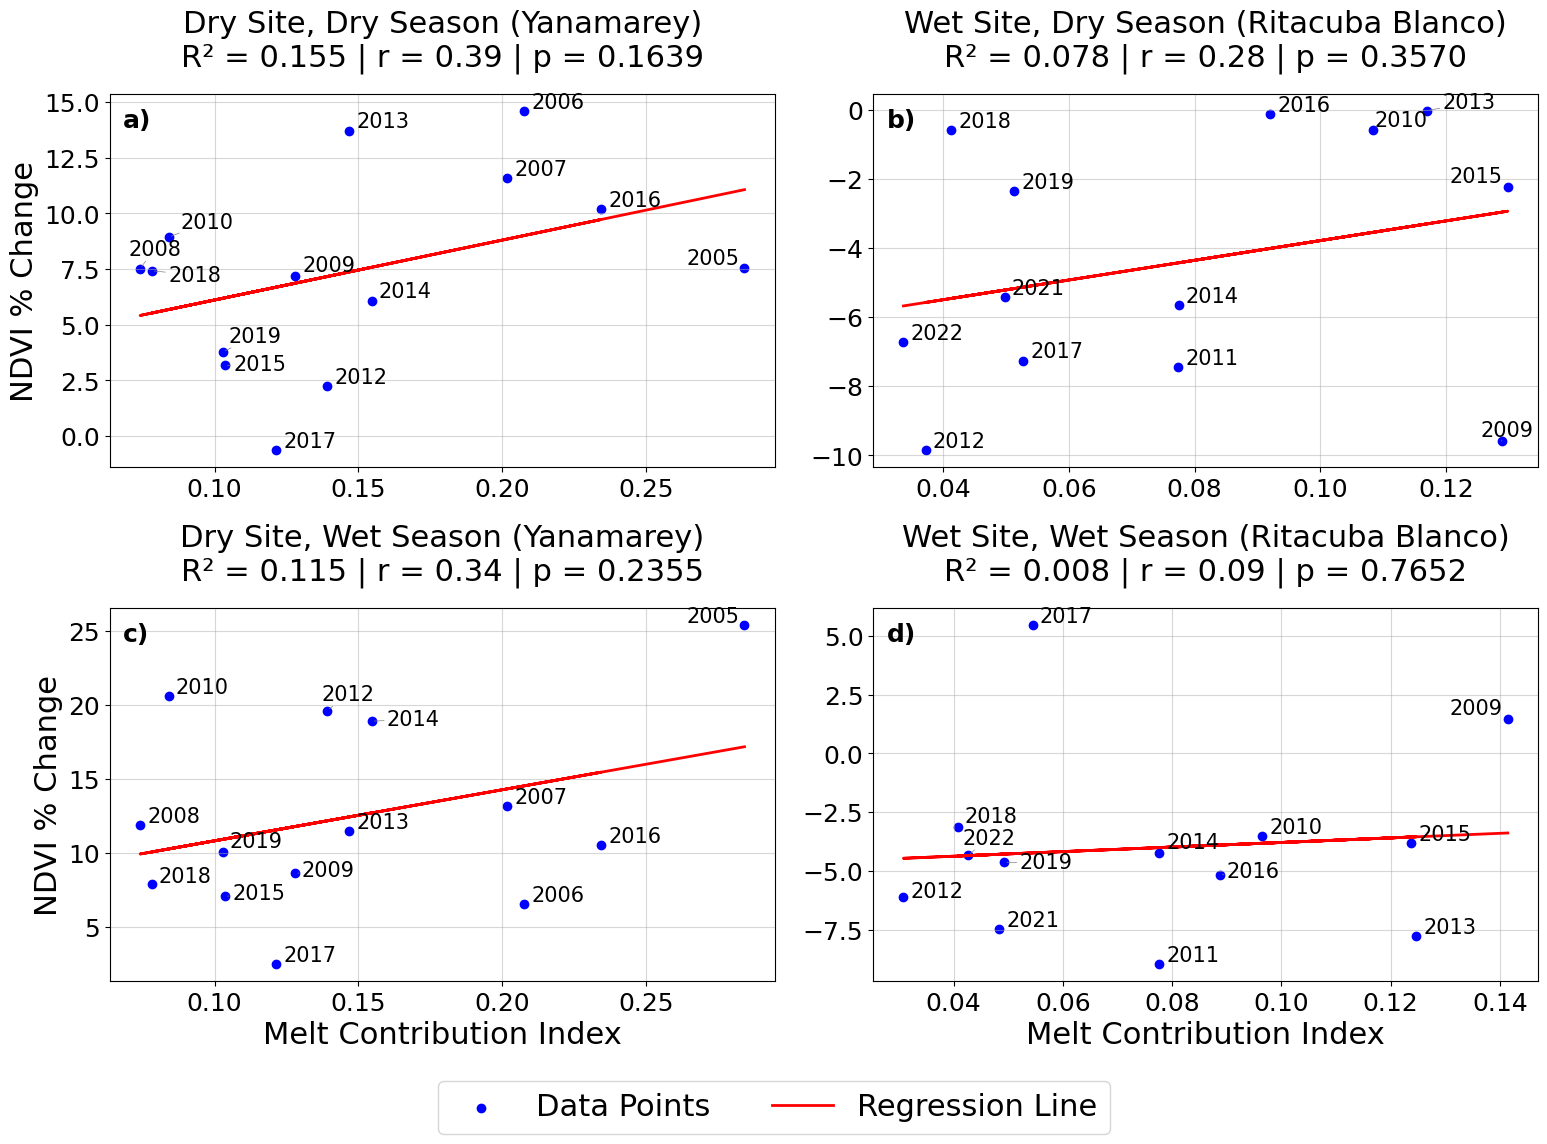

In [2]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text 

# Update this path to the location of the GlacierProject folder on your computer
BASE_DIR = '/path/to/GlacierProject' 

# Update global font sizes
plt.rcParams.update({
    'font.size': 24,          # General font size
    'axes.titlesize': 22,     # Subplot title size (a, b, c, d)
    'axes.labelsize': 22,     # X and Y axis labels
    'xtick.labelsize': 18,    # X-axis tick numbers
    'ytick.labelsize': 18,    # Y-axis tick numbers
    'legend.fontsize': 22     # Legend text size
})


# ==========================================
# 1. FILE PATHS & INITIAL SETUP
# ==========================================

NDVI_PATHS = {
    "yan": {
        "imp": os.path.join(BASE_DIR, "Intermediate", "NDVI", "YanImpNSmooth.csv"),
        "non": os.path.join(BASE_DIR, "Intermediate", "NDVI", "YanNonNSmooth.csv"),
    },
    "rb": {
        "imp": os.path.join(BASE_DIR, "Intermediate", "NDVI", "RBImpNSmooth.csv"),
        "non": os.path.join(BASE_DIR, "Intermediate", "NDVI", "RBNonNSmooth.csv"),
    }
}

CLIMATE_PATHS = {
    "yan": {
        "chirps": os.path.join(BASE_DIR, "RawData", "Climate", "Precipitation", "chirps_Yan.csv"),
        "mb": os.path.join(BASE_DIR, "RawData", "MassBalance", "MBA_Yanamarey_01.csv"),
    },
    "rb": {
        "chirps": os.path.join(BASE_DIR, "RawData", "Climate", "Precipitation", "chirps_RB.csv"),
        "mb": os.path.join(BASE_DIR, "RawData", "MassBalance", "MBA_Ritacuba_01.csv"),
    }
}

SITE_CONFIG = {
    "yan": {
        "wy_start": 10,
        "start_yr": 2000,
        "basin_area_km2": 4.17,
        "title_prefix": "Yanamarey"
    },
    "rb": {
        "wy_start": 1, 
        "start_yr": 1990,
        "basin_area_km2": 5.43, 
        "title_prefix": "Ritacuba Blanco"
    }
}

# ==========================================
# 2. SUBPLOT CONFIGURATIONS
# ==========================================
DRY_SITE = "yan"
WET_SITE = "rb"

PLOT_CONFIGS = [
    {"title": "Dry Site, Dry Season", "site": DRY_SITE, "months": [6, 7, 8], "wy_offset": 0},
    {"title": "Wet Site, Dry Season", "site": WET_SITE, "months": [1, 2, 3], "wy_offset": 1},
    {"title": "Dry Site, Wet Season", "site": DRY_SITE, "months": [2, 3, 4], "wy_offset": 0},
    {"title": "Wet Site, Wet Season", "site": WET_SITE, "months": [9, 10, 11], "wy_offset": 0} 
]

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def average_ndvi_by_month(ndvi_data, months):
    df = ndvi_data.copy()
    df['year'] = pd.to_datetime(df['time']).dt.year
    df['month'] = pd.to_datetime(df['time']).dt.month
    return df[df['month'].isin(months)].groupby('year')['NDVI_smoothed'].mean().reset_index()

def get_plot_data(site, months, wy_offset):
    """Loads and processes data for a specific site and season setup."""
    imp_ndvi = pd.read_csv(NDVI_PATHS[site]["imp"])
    non_ndvi = pd.read_csv(NDVI_PATHS[site]["non"])
    chirps = pd.read_csv(CLIMATE_PATHS[site]["chirps"])
    mb = pd.read_csv(CLIMATE_PATHS[site]["mb"])
    
    cfg = SITE_CONFIG[site]
    wy_month = cfg["wy_start"]
    start_yr = cfg["start_yr"]
    end_yr = 2024
    basin_area_km2 = cfg["basin_area_km2"]

    chirps["date"] = pd.to_datetime(chirps["date"], format="%Y-%m")
    chirps["year"] = chirps["date"].dt.year
    chirps["month"] = chirps["date"].dt.month
    chirps["precipitation"] = chirps["precip_mm"].astype(float)

    # Standard water year logic
    chirps["water_year"] = chirps["year"]
    if wy_month > 1:
        chirps.loc[chirps["month"] >= wy_month, "water_year"] += 1

    chirps_filtered = chirps[(chirps["water_year"] >= start_yr) & (chirps["water_year"] <= end_yr)]
    water_year_precip = chirps_filtered.groupby("water_year")["precipitation"].sum().reset_index()
    water_year_precip.rename(columns={'water_year': 'Year', 'precipitation': 'Precipitation'}, inplace=True)

    # --- APPLY LAG TO PRECIPITATION ---
    # Shifts precipitation forward so last year's precip aligns with current year's NDVI
    water_year_precip['Year'] += wy_offset 

    merged_data = water_year_precip.copy()

    imp_avg_ndvi = average_ndvi_by_month(imp_ndvi, months)
    merged_data = merged_data.merge(imp_avg_ndvi, how='left', left_on='Year', right_on='year')
    merged_data.rename(columns={'NDVI_smoothed': 'Imp_NDVI_Avg'}, inplace=True)

    non_avg_ndvi = average_ndvi_by_month(non_ndvi, months)
    merged_data = merged_data.merge(non_avg_ndvi, how='left', left_on='Year', right_on='year')
    merged_data.rename(columns={'NDVI_smoothed': 'Non_NDVI_Avg'}, inplace=True)

    merged_data["Percent_Change"] = ((merged_data["Imp_NDVI_Avg"] - merged_data["Non_NDVI_Avg"]) / merged_data["Non_NDVI_Avg"]) * 100

    mb["Year"] = mb["Year"].astype(int)
    merged_data = merged_data.merge(mb, on='Year', how='left')
    merged_data["Glacier_Area"] = merged_data["AreaNew"]

    mm_to_t = 1e3
    # Note: Precip is lagged by wy_offset here, MB is not.
    merged_data["Glacier_Melt_Water_Mass"] = (merged_data["Precipitation"] - merged_data["MB"]) * merged_data["Glacier_Area"] * mm_to_t
    merged_data["Precip_Water_Mass"] = merged_data["Precipitation"] * (basin_area_km2 - merged_data["Glacier_Area"]) * mm_to_t
    merged_data["Combined_Water_Mass"] = merged_data["Precip_Water_Mass"] + merged_data["Glacier_Melt_Water_Mass"]
    merged_data["MeltCont"] = merged_data["Glacier_Melt_Water_Mass"] / merged_data["Combined_Water_Mass"]

    merged_data['Year'] = merged_data['Year'].astype(str)
    
    return merged_data[['Year', 'MeltCont', 'Percent_Change']].dropna()

# ==========================================
# 4. PLOTTING
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

x_var = 'MeltCont'
y_var = 'Percent_Change'
scatter_handle, line_handle = None, None

for i, config in enumerate(PLOT_CONFIGS):
    ax = axes[i]
    # Pass wy_offset into the function
    df = get_plot_data(config["site"], config["months"], config["wy_offset"])
    
    X_vals = df[x_var].values
    y_vals = df[y_var].values
    X_reshape = X_vals.reshape(-1, 1)
    
    corr, p_value = stats.pearsonr(X_vals, y_vals)
    model = LinearRegression().fit(X_reshape, y_vals)
    y_pred = model.predict(X_reshape)
    r_squared = model.score(X_reshape, y_vals)
    
    scatter = ax.scatter(X_vals, y_vals, color='blue', label='Data Points')
    line, = ax.plot(X_vals, y_pred, color='red', linewidth=2, label='Regression Line')
    
    if i == 0:
        scatter_handle, line_handle = scatter, line
    
    # --- ANTI-OVERLAP TEXT ANNOTATIONS ---
    texts = []
    for idx, row in df.iterrows():
        texts.append(ax.text(row[x_var], row[y_var], str(row['Year']), fontsize=15))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
        
    # Only draw the X-axis label on the bottom row (indices 2 and 3)
    if i >= 2:
        ax.set_xlabel('Melt Contribution Index')
        
    # Only draw the Y-axis label on the left column (indices 0 and 2)
    if i % 2 == 0:
        ax.set_ylabel('NDVI % Change')
    ax.grid(True, alpha=0.5)
    
    # --- SUBPLOT LETTER & TITLE FORMATTING ---
    # Generates a), b), c), d) automatically
    subplot_letter = f"{chr(97 + i)})" 
    
    # Bold letter in top left corner
    ax.annotate(subplot_letter, xy=(0.02, 0.96), xycoords='axes fraction', 
                fontweight='bold', fontsize=18, va='top', ha='left')
    
    site_prefix = SITE_CONFIG[config["site"]]["title_prefix"]
    title_str = (f"{config['title']} ({site_prefix})\n"
                 f"R² = {r_squared:.3f} | r = {corr:.2f} | p = {p_value:.4f}")
    ax.set_title(title_str, pad=20)

plt.tight_layout()
# Increase this from 0.1 to 0.15 (or 0.18) to create more empty space at the bottom
fig.subplots_adjust(bottom=0.16) 

# Add bbox_to_anchor to precisely place the legend in that empty space
fig.legend([scatter_handle, line_handle], ['Data Points', 'Regression Line'], 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))

plt.show()

## NDVI Regression

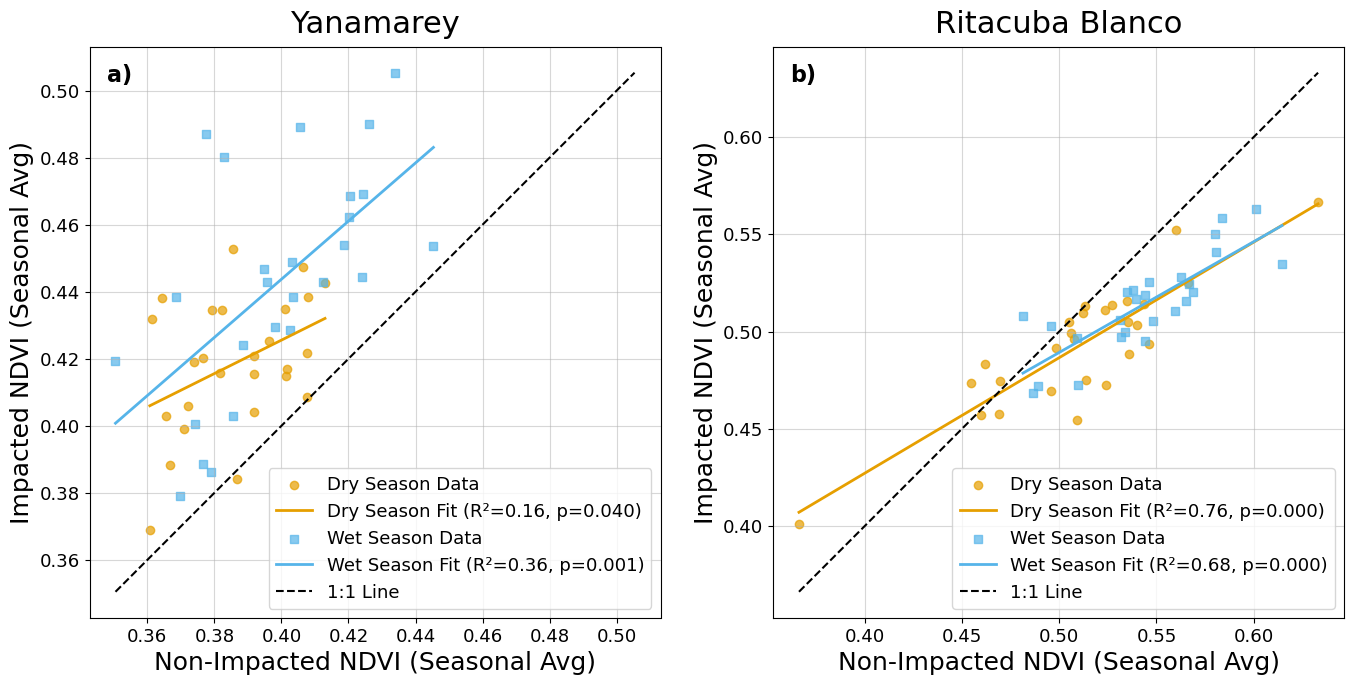

In [3]:
import pandas as pd
import numpy as np
import os
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ==========================================
# 1. GLOBAL SETTINGS & PATHS
# ==========================================
# Update this path to the location of the GlacierProject folder on your computer
BASE_DIR = '/path/to/GlacierProject' 

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13
})

NDVI_PATHS = {
    "yan": {
        "imp": os.path.join(BASE_DIR, "Intermediate", "NDVI", "YanImpNSmooth.csv"),
        "non": os.path.join(BASE_DIR, "Intermediate", "NDVI", "YanNonNSmooth.csv"),
    },
    "rb": {
        "imp": os.path.join(BASE_DIR, "Intermediate", "NDVI", "RBImpNSmooth.csv"),
        "non": os.path.join(BASE_DIR, "Intermediate", "NDVI", "RBNonNSmooth.csv"),
    }
}

# ==========================================
# 2. SITE & SEASON CONFIGURATIONS
# ==========================================
SITE_CONFIGS = [
    {
        "site": "yan",
        "title": "Yanamarey",
        "seasons": [
            {"label": "Dry Season", "months": [6, 7, 8], "year_shift": 0, "color": "#E69F00", "marker": "o"},
            {"label": "Wet Season", "months": [2, 3, 4], "year_shift": 0, "color": "#56B4E9", "marker": "s"}
        ]
    },
    {
        "site": "rb",
        "title": "Ritacuba Blanco",
        "seasons": [
            {"label": "Dry Season", "months": [1, 2, 3], "year_shift": 0, "color": "#E69F00", "marker": "o"},
            {"label": "Wet Season", "months": [9, 10, 11], "year_shift": 1, "color": "#56B4E9", "marker": "s"}
        ]
    }
]

# ==========================================
# 3. HELPER FUNCTION
# ==========================================
def get_ndvi_scatter_data(site, months, year_shift):
    imp_ndvi = pd.read_csv(NDVI_PATHS[site]["imp"])
    non_ndvi = pd.read_csv(NDVI_PATHS[site]["non"])
    
    def process_ndvi(df, name):
        d = df.copy()
        d['time'] = pd.to_datetime(d['time'])
        d['year'] = d['time'].dt.year + year_shift
        d['month'] = d['time'].dt.month
        
        return (d[d['month'].isin(months)]
                .groupby('year', as_index=False)['NDVI_smoothed']
                .mean()
                .rename(columns={'NDVI_smoothed': name}))

    imp_avg = process_ndvi(imp_ndvi, 'Imp_NDVI')
    non_avg = process_ndvi(non_ndvi, 'Non_NDVI')
    
    return imp_avg.merge(non_avg, on='year', how='outer').dropna()

# ==========================================
# 4. PLOTTING SETUP
# ==========================================
# Removed sharex=True and sharey=True so each plot scales independently
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ==========================================
# 5. PLOTTING LOOP
# ==========================================
for i, config in enumerate(SITE_CONFIGS):
    ax = axes[i]
    
    # We will collect all values for this specific site to calculate its own 1:1 line
    site_vals = []
    
    for season in config["seasons"]:
        df = get_ndvi_scatter_data(config["site"], season["months"], season["year_shift"])
        
        x_vals = df['Non_NDVI'].values
        y_vals = df['Imp_NDVI'].values
        
        # Store values for the local 1:1 line calculation
        site_vals.extend(x_vals)
        site_vals.extend(y_vals)
        
        # Correlation & Regression
        corr, p_value = stats.pearsonr(x_vals, y_vals)
        X_reshape = x_vals.reshape(-1, 1)
        model = LinearRegression().fit(X_reshape, y_vals)
        y_pred = model.predict(X_reshape)
        r_squared = model.score(X_reshape, y_vals)

        sort_idx = np.argsort(x_vals)

        # Plotting elements
        c = season["color"]
        m = season["marker"]
        l = season["label"]
        line_label = f"{l} Fit (R²={r_squared:.2f}, p={p_value:.3f})"

        ax.scatter(x_vals, y_vals, alpha=0.7, color=c, marker=m, label=f"{l} Data")
        ax.plot(x_vals[sort_idx], y_pred[sort_idx], linewidth=2, color=c, label=line_label)
    
    # --- Local 1:1 Line ---
    # Calculate min and max strictly for the current subplot
    vmin, vmax = min(site_vals), max(site_vals)
    ax.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1.5, color='black', label="1:1 Line")

    # --- Formatting ---
    subplot_letter = f"{chr(97 + i)})" 
    ax.annotate(subplot_letter, xy=(0.03, 0.97), xycoords='axes fraction', 
                fontweight='bold', fontsize=16, va='top', ha='left')

    ax.set_title(config["title"], pad=10)

    # Force square aspect ratio based on local limits
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.5)
    ax.legend(loc='lower right')

    # Add axis labels to both plots since they no longer share scales
    ax.set_xlabel("Non-Impacted NDVI (Seasonal Avg)")
    ax.set_ylabel("Impacted NDVI (Seasonal Avg)")

plt.tight_layout()
plt.show()

## Precipitation, Glacier Area, MCI

/var/folders/xs/s4fnywmn1r9df0yl9322m85m0000gn/T/ipykernel_37219/4020237942.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


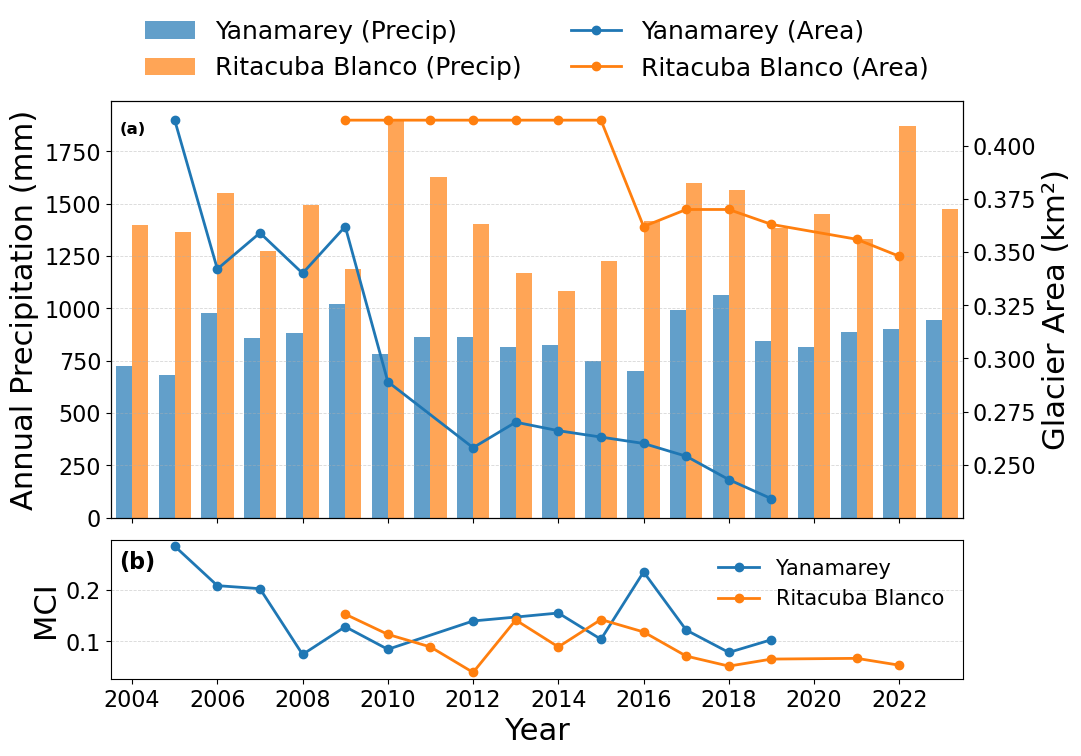

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

# -------------------------
# Configuration & Paths
# -------------------------
# Update this path to the location of the GlacierProject folder on your computer
BASE_DIR = '/path/to/GlacierProject' 

# Define the range of years you want to plot
start_year = 2005  # Replace with your desired start year
end_year = 2022    # Replace with your desired end year

# -------------------------
# Load and prepare data
# -------------------------
# 1. Original sparse data (Area and MCI)
filepath = os.path.join(BASE_DIR, 'Intermediate', 'Figure3CSV.csv')
yanFile = os.path.join(BASE_DIR, 'RawData', 'Climate', 'Precipitation', 'chirps_Yan.csv')
RBFile = os.path.join(BASE_DIR, 'RawData', 'Climate', 'Precipitation', 'chirps_RB.csv')

df = pd.read_csv(filepath).sort_values("year")

yan = df[df["glacier"] == "Yanamarey"]
rit = df[df["glacier"] == "Ritacuba Blanco"]

# 2. New continuous precipitation data
# Load Yanamarey precipitation
yan_precip_raw = pd.read_csv(yanFile)
yan_precip_raw['year'] = pd.to_datetime(yan_precip_raw['date']).dt.year
yan_precip_annual = yan_precip_raw.groupby('year')['precip_mm'].sum().reset_index()

# Load Ritacuba Blanco precipitation
rit_precip_raw = pd.read_csv(RBFile)
rit_precip_raw['year'] = pd.to_datetime(rit_precip_raw['date']).dt.year
rit_precip_annual = rit_precip_raw.groupby('year')['precip_mm'].sum().reset_index()

# Consistent, colorblind-safe colors
yan_color = "tab:blue"
rit_color = "tab:orange"

# -------------------------
# Create figure layout
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(11, 7.5),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
        "hspace": 0.08
    }
)

# -------------------------
# TOP PANEL: Precipitation (bars) + Glacier Area (lines)
# -------------------------
bar_width = 0.38

# Precipitation bars
ax_top.bar(
    yan_precip_annual["year"] - bar_width / 2,
    yan_precip_annual["precip_mm"],
    width=bar_width,
    color=yan_color,
    alpha=0.7,
    label="Yanamarey (Precip)"
)

ax_top.bar(
    rit_precip_annual["year"] + bar_width / 2,
    rit_precip_annual["precip_mm"],
    width=bar_width,
    color=rit_color,
    alpha=0.7,
    label="Ritacuba Blanco (Precip)"
)

ax_top.set_ylabel("Annual Precipitation (mm)", fontsize=22)
ax_top.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# Twin axis for glacier area
ax_area = ax_top.twinx()

ax_area.plot(
    yan["year"],
    yan["glacier_area_sqkm"],
    color=yan_color,
    marker="o",
    linewidth=2,
    label="Yanamarey (Area)"
)

ax_area.plot(
    rit["year"],
    rit["glacier_area_sqkm"],
    color=rit_color,
    marker="o",
    linewidth=2,
    label="Ritacuba Blanco (Area)"
)

ax_area.set_ylabel("Glacier Area (km²)", fontsize=22)

# Combined legend for top panel
handles1, labels1 = ax_top.get_legend_handles_labels()
handles2, labels2 = ax_area.get_legend_handles_labels()

ax_top.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False,
    fontsize=18
)

# Panel label
ax_top.text(
    0.01, 0.95, "(a)",
    transform=ax_top.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

# -------------------------
# BOTTOM PANEL: Melt Contribution Index (MCI)
# -------------------------
ax_bottom.plot(
    yan["year"],
    yan["mci"],
    color=yan_color,
    marker="o",
    linewidth=2,
    label="Yanamarey"
)

ax_bottom.plot(
    rit["year"],
    rit["mci"],
    color=rit_color,
    marker="o",
    linewidth=2,
    label="Ritacuba Blanco"
)

ax_bottom.set_ylabel("MCI", fontsize=22)
ax_bottom.set_xlabel("Year", fontsize=22)
ax_bottom.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

ax_bottom.legend(frameon=False, fontsize=15)

# Panel label
ax_bottom.text(
    0.01, 0.92, "(b)",
    transform=ax_bottom.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)

# -------------------------
# Final formatting
# -------------------------

# Set the x-axis limits with padding so the outer bars aren't cut off
ax_bottom.set_xlim(start_year - 1.5, end_year + 1.5)

# Clean integer ticks for the x-axis
ax_bottom.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in [ax_top, ax_bottom, ax_area]:
    ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()